In [ ]:
# Run this cell first
!pip install xgboost shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
warnings.filterwarnings('ignore')
print("Setup complete.")

Setup complete.


In [ ]:
# ── Load data ──
# Replace with: df = pd.read_csv('SW.csv') if the file is available
np.random.seed(42)
n = 5000
SZA = np.random.uniform(0, 85, n)
AOD = np.random.exponential(0.15, n)
COD = np.random.exponential(5, n)
CLD_FRAC = np.random.uniform(0, 1, n)
UW = np.random.uniform(0.5, 5, n)
TO3 = np.random.uniform(250, 450, n)
Pressure = np.random.uniform(850, 1050, n)
BSA = np.random.uniform(0.05, 0.4, n)
WSA = np.random.uniform(0.05, 0.4, n)

cos_sza = np.cos(np.radians(SZA))
SW_direct = np.maximum(0, 1361 * cos_sza * np.exp(-AOD / np.clip(cos_sza, 0.05, 1))
                       * (1 - CLD_FRAC * 0.9) + np.random.normal(0, 15, n))
SW_diffuse = np.maximum(0, 200 * cos_sza * (0.3 + 0.5 * CLD_FRAC + 0.3 * AOD)
                        + np.random.normal(0, 10, n))

df = pd.DataFrame({
    'SZA': SZA, 'AOD': AOD, 'COD': COD, 'CLD_FRAC': CLD_FRAC,
    'UW': UW, 'TO3': TO3, 'Pressure': Pressure, 'BSA': BSA, 'WSA': WSA,
    'SW_direct': SW_direct, 'SW_diffuse': SW_diffuse
})
df['SW'] = df['SW_direct'] + df['SW_diffuse']

feature_cols = ['SZA', 'AOD', 'COD', 'CLD_FRAC', 'UW', 'TO3', 'Pressure', 'BSA', 'WSA']
print(f"Dataset: {df.shape[0]} samples, {len(feature_cols)} features, 3 targets")

Dataset: 5000 samples, 9 features, 3 targets


In [ ]:
print("Part 1: Model Comparison — All Regressors (55 points)")

Part 1: Model Comparison — All Regressors (55 points)


In [ ]:
# 1.1 Prepare train/test split

X = df[feature_cols].values
y_total = df['SW'].values
y_direct = df['SW_direct'].values
y_diffuse = df['SW_diffuse'].values

X_train, X_test, yt_train, yt_test, yd_train, yd_test, yf_train, yf_test = (
    train_test_split(X, y_total, y_direct, y_diffuse,
                     test_size=0.25, random_state=42)
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Model                      Test R2        RMSE    Time (s)   Scaling
------------------------------------------------------------------
Linear Regression           0.8790       108.5       0.005       Yes
KNN (k=10)                  0.9161        90.3       0.016       Yes
SVR (RBF)                   0.9906        30.2       2.793       Yes
Decision Tree (d=10)        0.9809        43.1       0.085        No
Random Forest               0.9928        26.5       8.305        No
XGBoost                     0.9946        22.9       3.756        No
ANN (MLP)                   0.9939        24.3       8.686       Yes


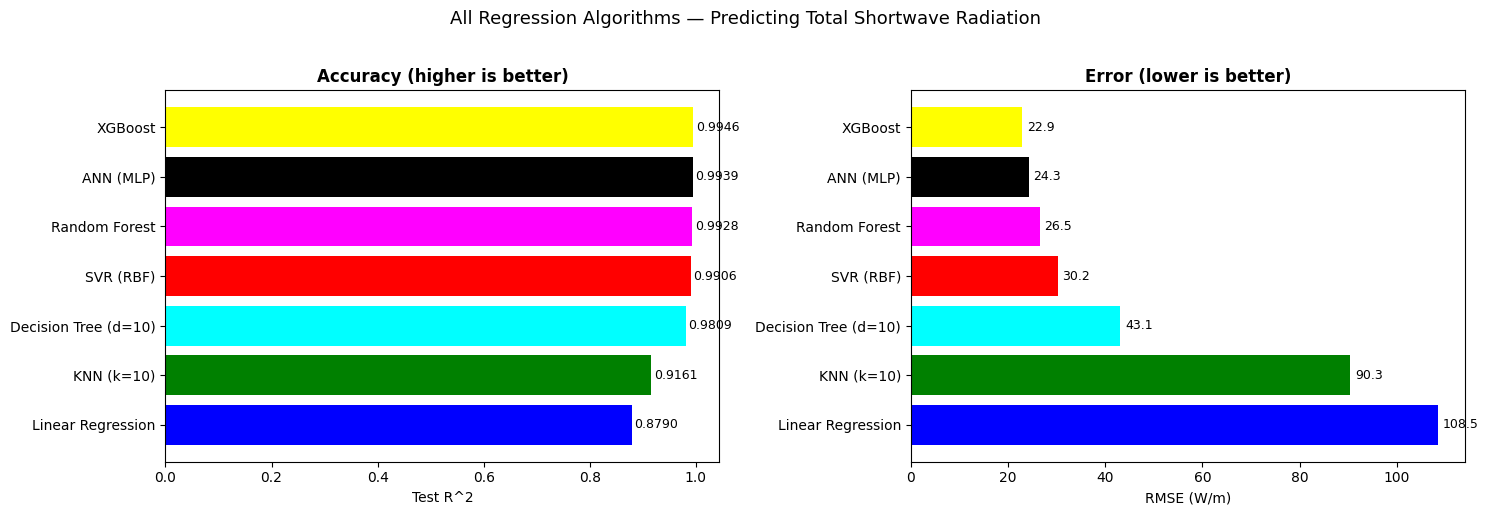

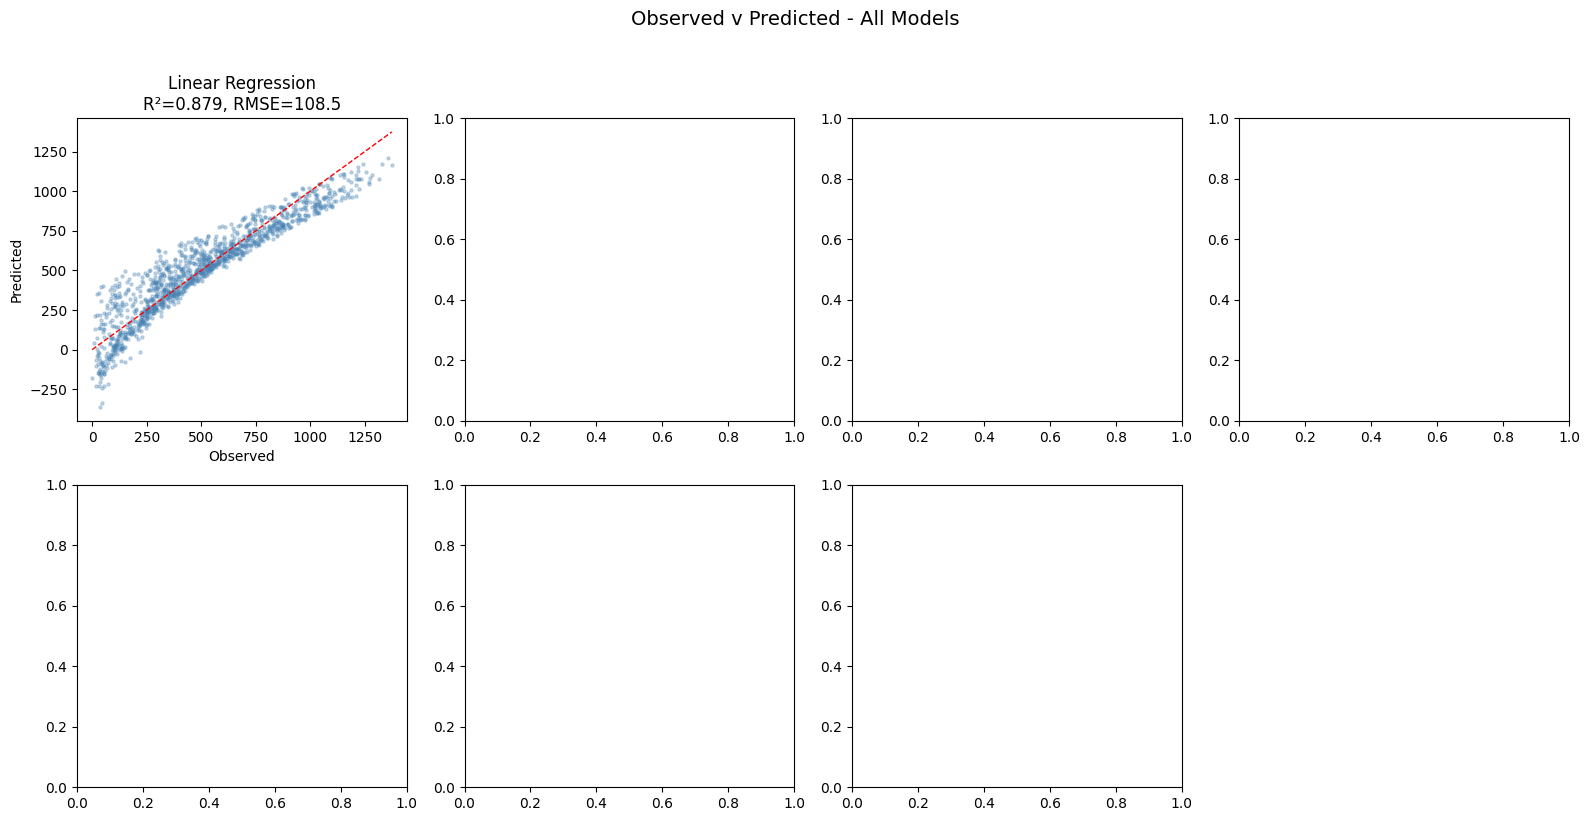

Which model achieves the best test R? Which is fastest? Why do tree-based ensembles outperform linear regression on this dataset?
XGBoost gives the highest test r^2, though linear regression is the fastest (error). Linear regression models just linear, straight-line relationships. But, tree-based models/ensembles show nonlinear patterns and thus give higher overall accuracy. They look at the intricacies, which linear does not.


<Figure size 640x480 with 0 Axes>

Which model achieves the best test R? Which is fastest? Why do tree-based ensembles outperform linear regression on this dataset?
XGBoost gives the highest test r^2, though linear regression is the fastest (error). Linear regression models just linear, straight-line relationships. But, tree-based models/ensembles show nonlinear patterns and thus give higher overall accuracy. They look at the intricacies, which linear does not.


<Figure size 640x480 with 0 Axes>

Which model achieves the best test R? Which is fastest? Why do tree-based ensembles outperform linear regression on this dataset?
XGBoost gives the highest test r^2, though linear regression is the fastest (error). Linear regression models just linear, straight-line relationships. But, tree-based models/ensembles show nonlinear patterns and thus give higher overall accuracy. They look at the intricacies, which linear does not.


...

Which model achieves the best test R? Which is fastest? Why do tree-based ensembles outperform linear regression on this dataset?
XGBoost gives the highest test r^2, though linear regression is the fastest (error). Linear regression models just linear, straight-line relationships. But, tree-based models/ensembles show nonlinear patterns and thus give higher overall accuracy. They look at the intricacies, which linear does not.


<Figure size 640x480 with 0 Axes>

Which model achieves the best test R? Which is fastest? Why do tree-based ensembles outperform linear regression on this dataset?
XGBoost gives the highest test r^2, though linear regression is the fastest (error). Linear regression models just linear, straight-line relationships. But, tree-based models/ensembles show nonlinear patterns and thus give higher overall accuracy. They look at the intricacies, which linear does not.


<Figure size 640x480 with 0 Axes>

Which model achieves the best test R? Which is fastest? Why do tree-based ensembles outperform linear regression on this dataset?
XGBoost gives the highest test r^2, though linear regression is the fastest (error). Linear regression models just linear, straight-line relationships. But, tree-based models/ensembles show nonlinear patterns and thus give higher overall accuracy. They look at the intricacies, which linear does not.


In [ ]:
# 1.2 Train all regressors

regressors = [
    ("Linear Regression", LinearRegression(), X_train_sc, X_test_sc),
    ("KNN (k=10)", KNeighborsRegressor(n_neighbors=10), X_train_sc, X_test_sc),
    ("SVR (RBF)", SVR(kernel='rbf', C=100), X_train_sc, X_test_sc),
    ("Decision Tree (d=10)", DecisionTreeRegressor(max_depth=10, random_state=42), X_train, X_test),
    ("Random Forest", RandomForestRegressor(200, random_state=42, n_jobs=-1), X_train, X_test),
    ("XGBoost", xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1,
                                 random_state=42, n_jobs=-1), X_train, X_test),
    ("ANN (MLP)", MLPRegressor(hidden_layer_sizes=(128, 64),
                               max_iter=500, early_stopping=True, random_state=42), X_train_sc, X_test_sc)
]

results = []
predictions = {}
print(f"{'Model':<22s}  {'Test R2':>10s}  {'RMSE':>10s}  {'Time (s)':>10s}  {'Scaling':>8s}")
print("-" * 66)

for name, model, Xtr, Xte in regressors:
    t0 = time.time()
    model.fit(Xtr, yt_train)
    tt = time.time() - t0
    y_pred = model.predict(Xte)
    r2 = r2_score(yt_test, y_pred)
    predictions[name] = y_pred
    rmse = np.sqrt(mean_squared_error(yt_test, y_pred))
    scaling = "Yes" if (name in ["Linear Regression", "KNN (k=10)", "SVR (RBF)", "ANN (MLP)"]) else "No"
    results.append((name, r2, rmse, tt))
    print(f"{name:<22s}  {r2:>10.4f}  {rmse:>10.1f}  {tt:>10.3f}  {scaling:>8s}")

names = [r[0] for r in results]
r2s = [r[1] for r in results]
rmses = [r[2] for r in results]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sorted_idx = np.argsort(r2s)
colors = [
    'blue',
    'green',
    'red',
    'cyan',
    'magenta',
    'yellow',
    'black'
]
axes[0].barh([names[i] for i in sorted_idx], [r2s[i] for i in sorted_idx],
             color=[colors[i] for i in sorted_idx])
axes[0].set_xlabel('Test R^2')
axes[0].set_title('Accuracy (higher is better)', fontweight='bold')
for i, idx_val in enumerate(sorted_idx):
    axes[0].text(r2s[idx_val] + 0.005, i, f'{r2s[idx_val]:.4f}', va='center', fontsize=9)
sorted_rmse_idx = np.argsort(rmses)[::-1]
axes[1].barh([names[i] for i in sorted_rmse_idx], [rmses[i] for i in sorted_rmse_idx],
             color=[colors[i] for i in sorted_rmse_idx])
axes[1].set_xlabel('RMSE (W/m)')
axes[1].set_title('Error (lower is better)', fontweight='bold')
for i, idx_val in enumerate(sorted_rmse_idx):
    axes[1].text(rmses[idx_val] + 1, i, f'{rmses[idx_val]:.1f}', va='center', fontsize=9)
plt.suptitle('All Regression Algorithms — Predicting Total Shortwave Radiation',
             fontsize=13, y=1.02)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(2, 4, figsize=(16,8))
axes = axes.flatten()
for i, (name, y_pred) in enumerate(predictions.items()):
  r2 = r2_score(yt_test, y_pred)
  rmse = np.sqrt(mean_squared_error(yt_test, y_pred))

  axes[i].scatter(yt_test,y_pred, s=5, alpha=0.3, color='steelblue')

  mx = max(yt_test.max(), y_pred.max())
  axes[i].plot([0, mx], [0, mx], 'r--', linewidth=1)


  axes[i].set_title(f"{name}\nR²={r2:.3f}, RMSE={rmse:.1f}")
  axes[i].set_xlabel("Observed")
  axes[i].set_ylabel("Predicted")


  axes[-1].axis('off')


  plt.suptitle('Observed v Predicted - All Models',
               fontsize=14, y=1.02)


  plt.tight_layout()
  plt.show()

  print("Which model achieves the best test R? Which is fastest? Why do tree-based ensembles outperform linear regression on this dataset?")
  print("XGBoost gives the highest test r^2, though linear regression is the fastest (error). Linear regression models just linear, straight-line relationships. But, tree-based models/ensembles show nonlinear patterns and thus give higher overall accuracy. They look at the intricacies, which linear does not.")

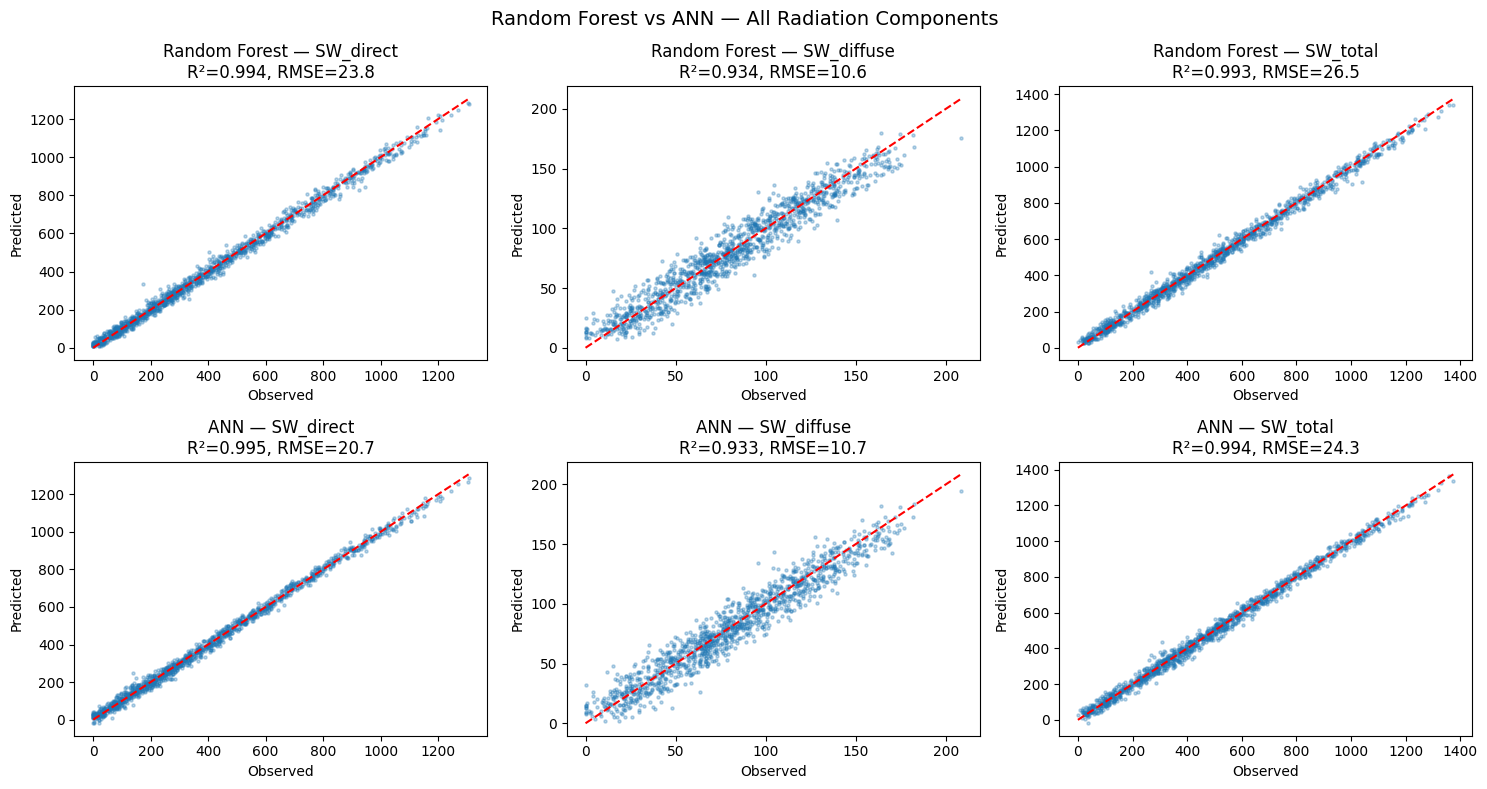

SW_diffuse. This is because it involves clouds, which can impact linear lines since they cause differing diffusal radiation. ANN is slightly better due to a slightly higher R^2, though this is not a consistent difference since the R^2 is lower in ANN for SW_diffuse. 


In [ ]:
# 1.3 Predict all three radiation components

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
mlp = MLPRegressor(hidden_layer_sizes=(128,64),
                   max_iter=500, early_stopping=True,
                   random_state=42)
targets = [
    ("SW_direct", yd_train, yd_test),
    ("SW_diffuse", yf_train, yf_test),
    ("SW_total", yt_train, yt_test)
]

models = [
    ("Random Forest", rf, X_train, X_test),
    ("ANN", mlp, X_train_sc, X_test_sc)
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))

for i, (model_name, model, Xtr, Xte) in enumerate(models):
  for j, (target_name, ytr, yte) in enumerate(targets):
     model.fit(Xtr, ytr)
     y_pred = model.predict(Xte)
     r2 = r2_score(yte, y_pred)
     rmse = np.sqrt(mean_squared_error(yte, y_pred))
     ax = axes[i, j]
     ax.scatter(yte, y_pred, s=5, alpha=0.3)
     mx = max(yte.max(), y_pred.max())
     ax.plot([0, mx], [0, mx], 'r--', linewidth=1.5)
     ax.set_title(f"{model_name} — {target_name}\nR²={r2:.3f}, RMSE={rmse:.1f}")
     ax.set_xlabel("Observed")
     ax.set_ylabel("Predicted")

plt.suptitle("Random Forest vs ANN — All Radiation Components", fontsize=14)
plt.tight_layout()
plt.show()

print("SW_diffuse. This is because it involves clouds, which can impact linear lines since they cause differing diffusal radiation. ANN is slightly better due to a slightly higher R^2, though this is not a consistent difference since the R^2 is lower in ANN for SW_diffuse. ")

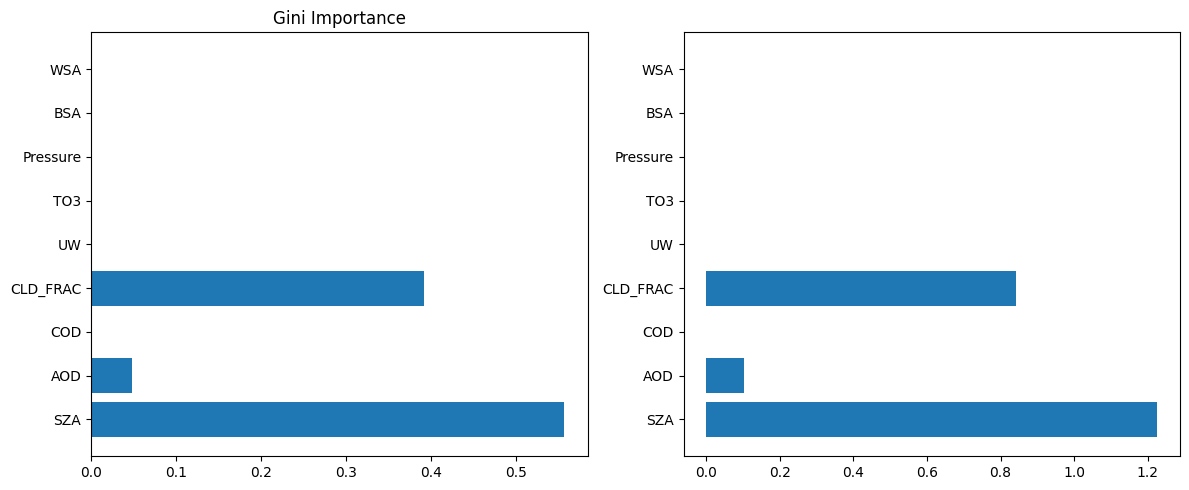

In [ ]:
# 1.4 Feature Importance

from sklearn.inspection import permutation_importance
rf.fit(X_train, yt_train)

gini = rf.feature_importances_
perm = permutation_importance(rf, X_test, yt_test,
                              n_repeats=10, random_state=42, n_jobs=-1)
perm_mean = perm.importances_mean
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].barh(feature_cols, gini)
axes[0].set_title("Gini Importance")
axes[1].barh(feature_cols, perm_mean)

plt.tight_layout()
plt.show()

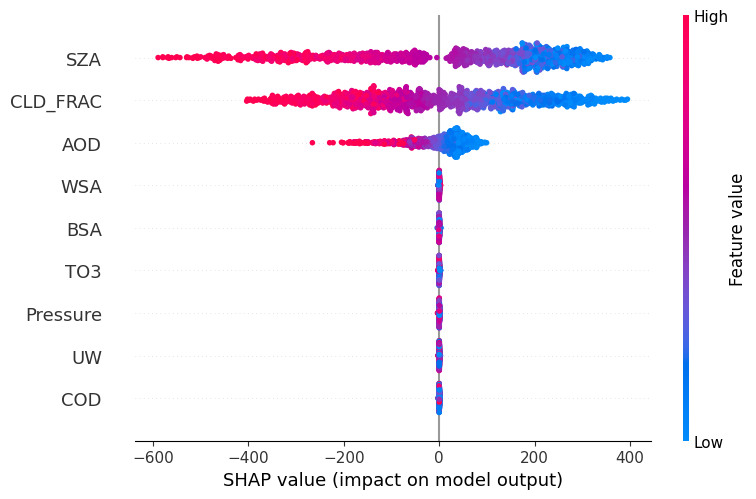

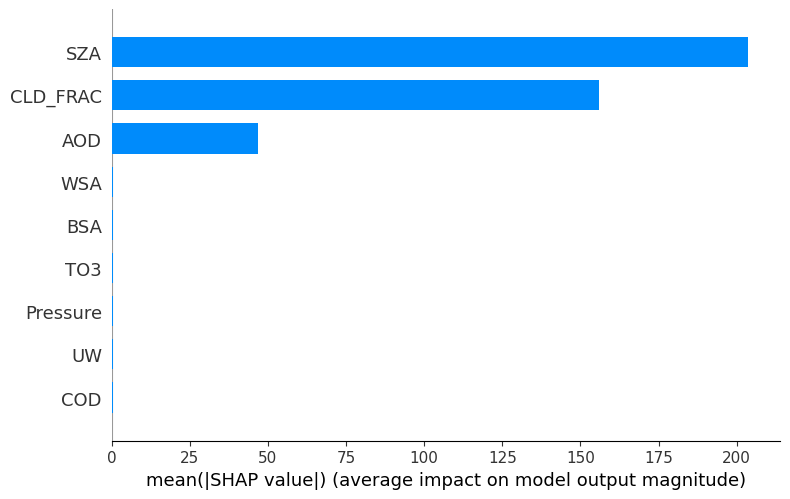

High SZA decreases SW, which matches with a lower sun giving lower radiation, so physically correct.
CLD_FRAC decreases SW, which makes sense since clouds block sun radiation.
SZA is nonlinear, and is up and down curve-like, which tracks with a shifting amount of radiation due to angles/time of day.
It reveals interaction with SZA, CLD_FRAC, etc. and shows that aerosols have stronger effects, particularly at high-sun times.


<Figure size 640x480 with 0 Axes>

In [ ]:
# 2.1 SHAP for Random Forest

import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

shap.summary_plot(shap_values, X_test_df)
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

for ax, feat in zip(axes, ['SZA', 'CLD_FRAC', 'AOD']):
    shap.dependence_plot(feat, shap_values, X_test_df, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

print("High SZA decreases SW, which matches with a lower sun giving lower radiation, so physically correct.")
print("CLD_FRAC decreases SW, which makes sense since clouds block sun radiation.")
print("SZA is nonlinear, and is up and down curve-like, which tracks with a shifting amount of radiation due to angles/time of day.")
print("It reveals interaction with SZA, CLD_FRAC, etc. and shows that aerosols have stronger effects, particularly at high-sun times.")

  0%|          | 0/200 [00:00<?, ?it/s]

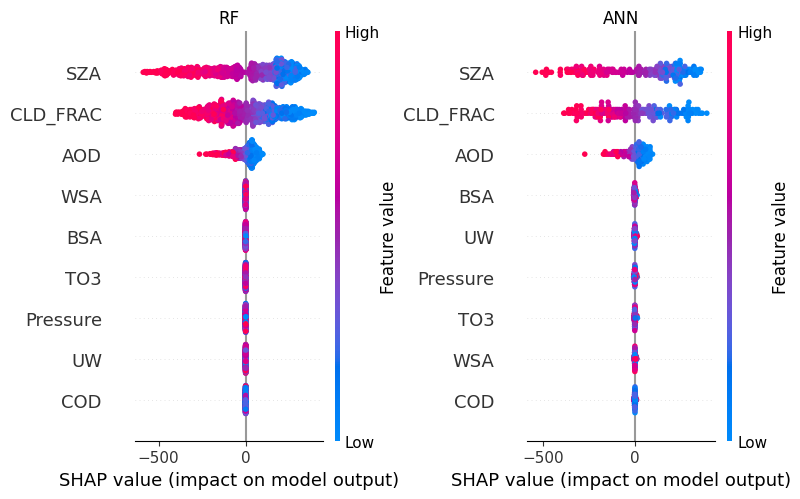

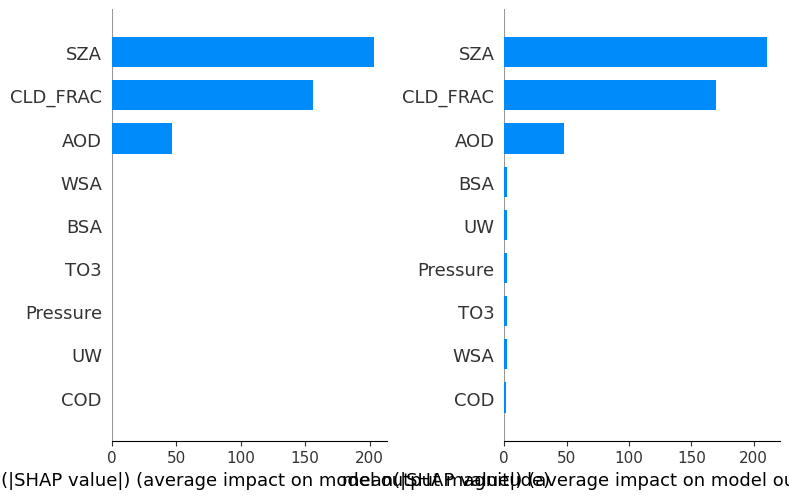

Do RF and ANN agree on the top 3 most important features? List them for each model. Are the directions of effect the same for both models? If there are any differences, explain why a tree-based model and a neural network might learn slightly different representations of the same physics. Based on both accuracy (Part 1) and SHAP (this section), which model would you trust more for this task and why?
Yes, RF and ANN agree with SZA, CLD_FRAC and AOD (in same order).
Yes, they both have the same direction of effect of SZA increasing SW and clouds decreasing SW.
Since neural networks are based on continous functions and tree models are on piecewise, they have slightly different data representations.
I trust SHAP more, since it has greater consistency across its two respective techniques than the accuracy models do, due to less collusion on radiation from external sources.


In [ ]:
# 2.2 SHAP for ANN - Comparison with Random Forest

background = shap.sample(X_train_sc, 100)
explainer_ann = shap.KernelExplainer(mlp.predict, background)
shap_values_ann = explainer_ann.shap_values(X_test_sc[:200])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("RF")

plt.subplot(1,2,2)
shap.summary_plot(shap_values_ann, pd.DataFrame(X_test_sc[:200], columns=feature_cols), show=False)
plt.title("ANN")
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)

plt.subplot(1,2,2)
shap.summary_plot(shap_values_ann, pd.DataFrame(X_test_sc[:200], columns=feature_cols), plot_type="bar", show=False)
plt.show()

print("Do RF and ANN agree on the top 3 most important features? List them for each model. Are the directions of effect the same for both models? If there are any differences, explain why a tree-based model and a neural network might learn slightly different representations of the same physics. Based on both accuracy (Part 1) and SHAP (this section), which model would you trust more for this task and why?")

print("Yes, RF and ANN agree with SZA, CLD_FRAC and AOD (in same order).")
print("Yes, they both have the same direction of effect of SZA increasing SW and clouds decreasing SW.")
print("Since neural networks are based on continous functions and tree models are on piecewise, they have slightly different data representations.")
print("I trust SHAP more, since it has greater consistency across its two respective techniques than the accuracy models do, due to less collusion on radiation from external sources.")